## TSPN

### import model

In [17]:
import argparse
from model.TSPN import Transparent_Signal_Processing_Network
from trainer.trainer_basic import Basic_plmodel

import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
print(model.network)
state_dict = torch.load("./save/test/model_seu/tspn3.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)

Running experiment: model_TSPNtime21-17-03-40_datasetSEU_010_Basic_it0
# build signal processing layers
# build feature extractor layers
# build classifier
Transparent_Signal_Processing_Network(
  (signal_processing_layers): ModuleList(
    (0): SignalProcessingLayer(
      (norm): InstanceNorm1d(2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (weight_connection): Linear(in_features=2, out_features=12, bias=False)
      (signal_processing_modules): SignalProcessingModuleDict(
        (HT): HilbertTransform()
        (WF): WaveFilters()
        (I): Identity()
      )
      (skip_connection): Linear(in_features=2, out_features=12, bias=False)
    )
    (1-3): 3 x SignalProcessingLayer(
      (norm): InstanceNorm1d(12, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (weight_connection): Linear(in_features=12, out_features=12, bias=False)
      (signal_processing_modules): SignalProcessingModuleDict(
        (HT): HilbertTransform()
     

<All keys matched successfully>

### plot signal function

In [13]:
def get_TSPN_signal(model, signal,i):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
            if idx == i:
                break
    return signal

def compute_frequency_domain(signal):
    fft_values = torch.fft.rfft(signal)
    fft_values = fft_values.detach().cpu().numpy()
    # 去除直流项
    fft_values[0] = 0
    return np.abs(fft_values)

def plot_signal(signal, savename):
    plt.rcParams['font.family'] = 'Times New Roman'
    fig, axs = plt.subplots(2, 2, figsize=(16, 4))

    for i in range(2):
        signal_time = signal[i,:]
        signal_time = (signal_time - signal_time.mean()) / (signal_time.std(unbiased=False) + 1e-8)
        signal_fft = compute_frequency_domain(signal_time)
        t = np.linspace(0, 4096/5120, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        
        axs[i,0].plot(t, signal_time,linewidth=1.0 ,c='#AF5F3C')
        axs[i,1].plot(signal_fft,linewidth=1.0 ,c='#6A4028')
        axs[i,0].set_ylabel(f'Amplitude', fontsize=18)
        axs[i,1].set_ylabel(f'Amplitude', fontsize=18)
        if i == 1:
            axs[i,0].set_xlabel('Time (s)', fontsize=18)
            axs[i,1].set_xlabel('Frequency (Hz)', fontsize=18)
    # fig.tight_layout()
    plt.savefig('save/figure/seu/signal/' + savename)
    # plt.show()

def plot_ori_signal(number, signal, savename):
    plt.rcParams['font.family'] = 'Times New Roman'
    print(signal.shape)
    test_signal = signal[number,:,:].unsqueeze(0)
    print(test_signal.shape)
    fig, axs = plt.subplots(2, 2, figsize=(16, 4))
    for i in range(2):
        print(test_signal.shape)
        # 使用z-score
        signal_time = test_signal[0,:,i]
        signal_time = (signal_time - signal_time.mean()) / (signal_time.std(unbiased=False) + 1e-8)
        signal_fft = compute_frequency_domain(signal_time)
        t = np.linspace(0, 4096/5120, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        
        axs[i,0].plot(t, signal_time,linewidth=0.5 ,c='#5291B2')
        axs[i,1].plot(signal_fft,linewidth=0.5 ,c='#283D7E')
        axs[i,0].set_ylabel(f'Amplitude', fontsize=18)
        axs[i,1].set_ylabel(f'Amplitude', fontsize=18)
        if i == 1:
            axs[i,0].set_xlabel('Time (s)', fontsize=18)
            axs[i,1].set_xlabel('Frequency (Hz)', fontsize=18)
    # fig.tight_layout()
    # plt.show()
    plt.savefig('save/figure/seu/signal/' + savename + '_original.svg')

### data & plot_signal

(1270, 4096, 2)
{np.float64(0.0): 253, np.float64(1.0): 507, np.float64(2.0): 761, np.float64(3.0): 1015, np.float64(4.0): 1269}
torch.Size([1270, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1270, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1270, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1270, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1270, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])
torch.Size([1, 4096, 2])


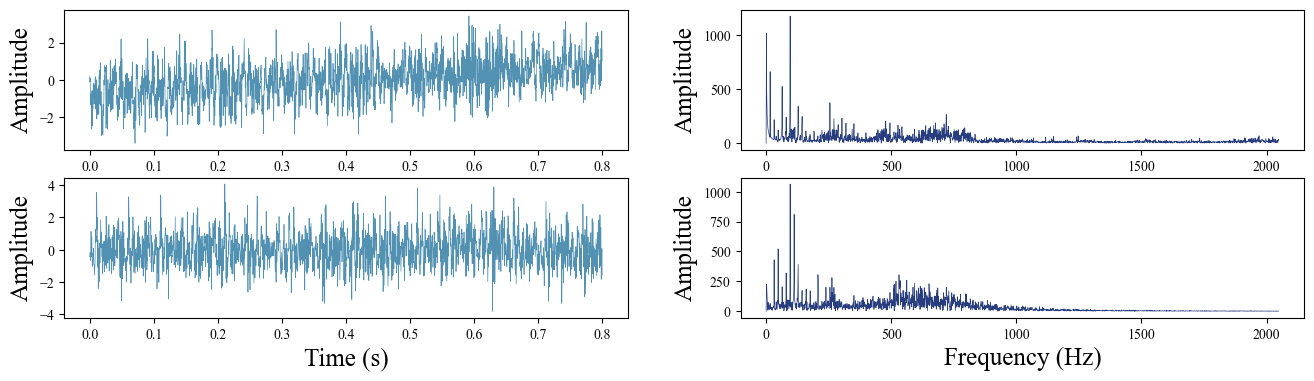

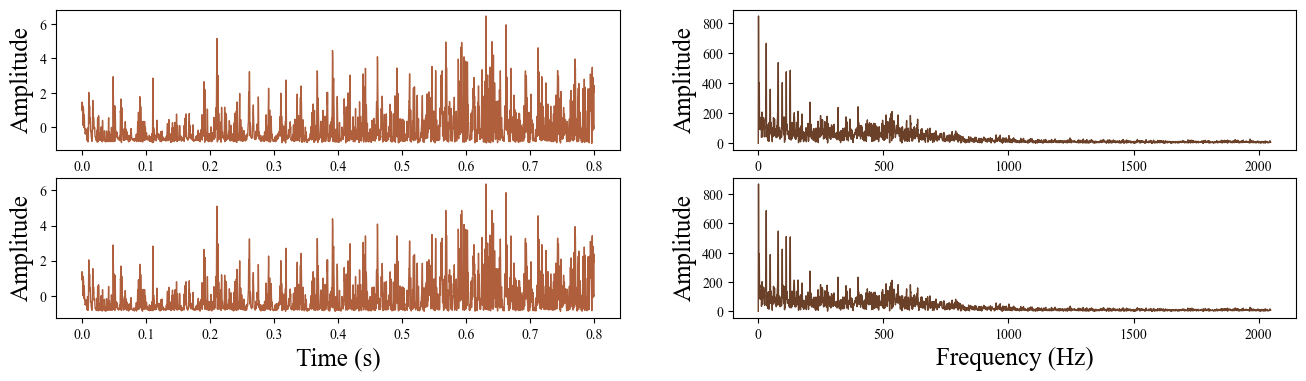

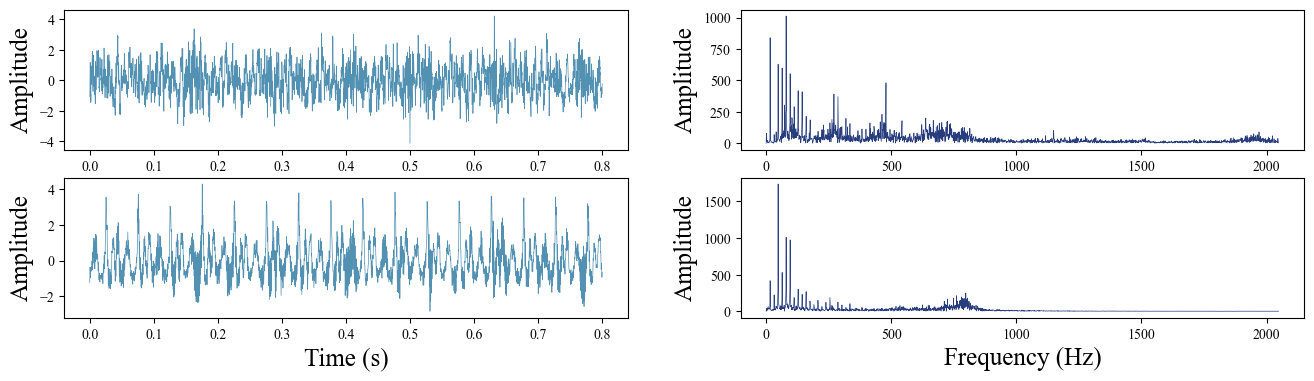

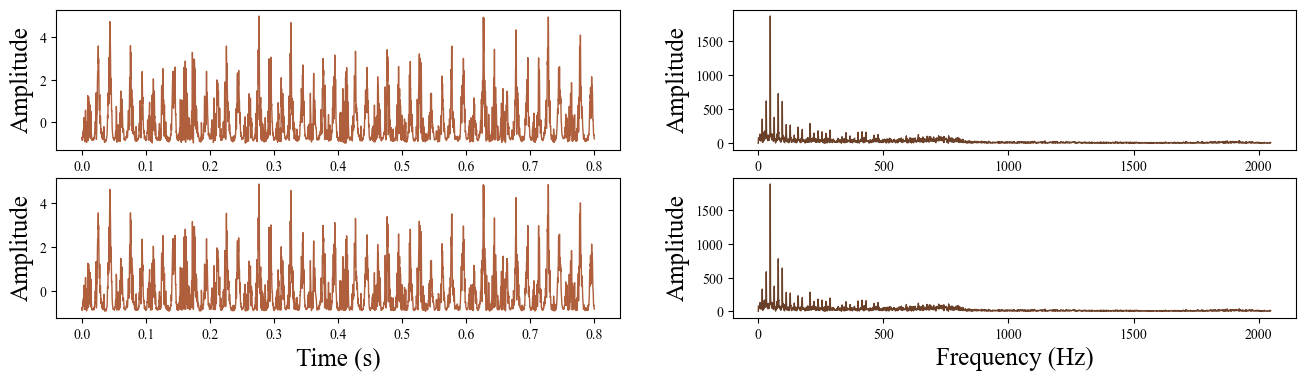

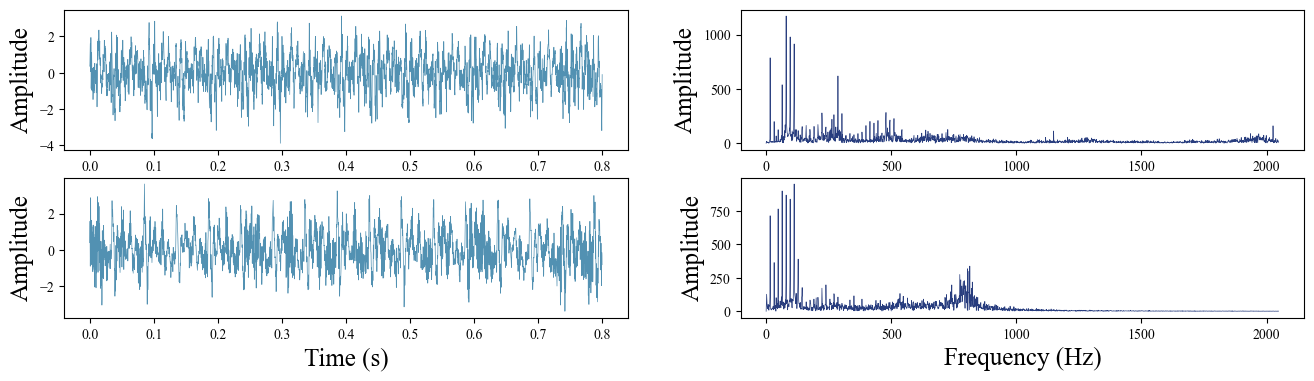

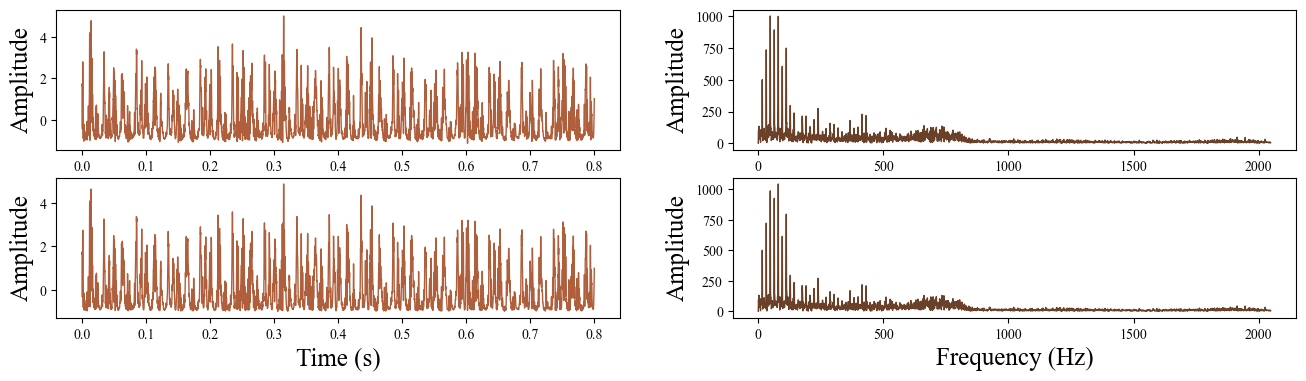

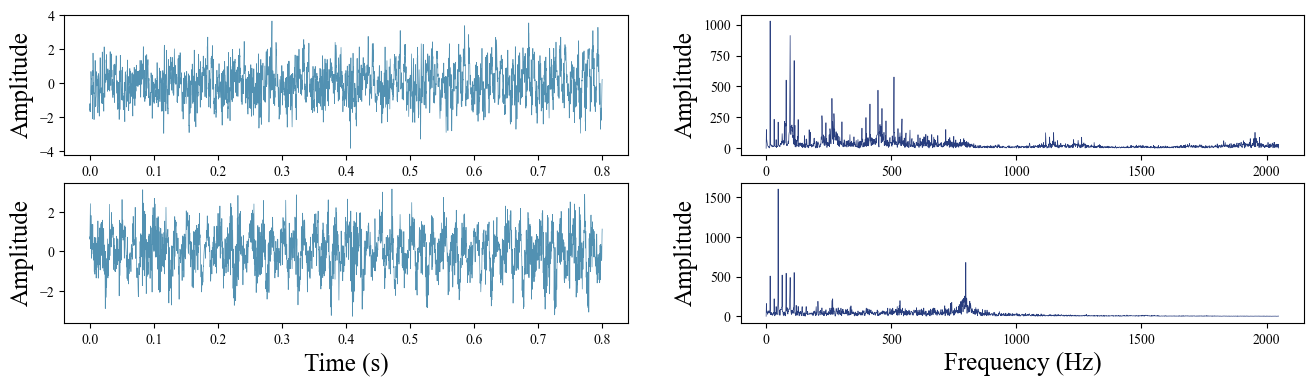

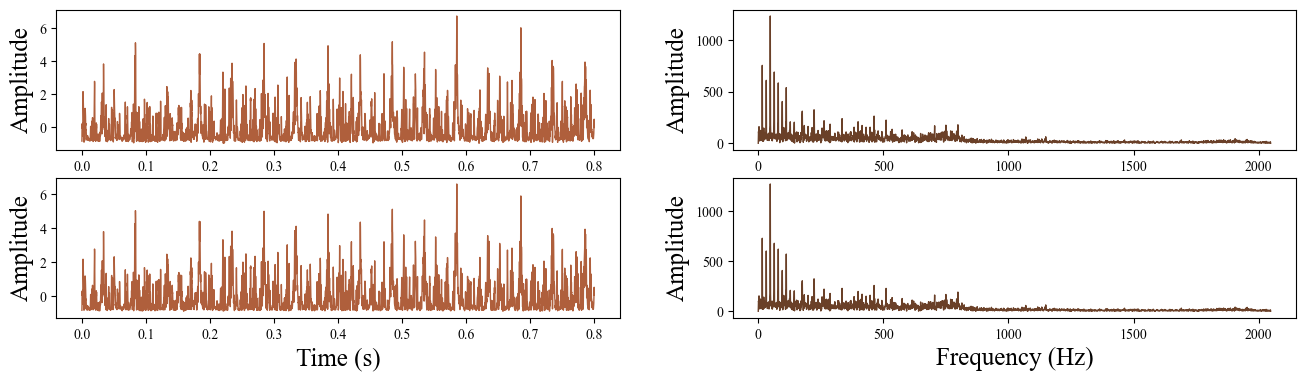

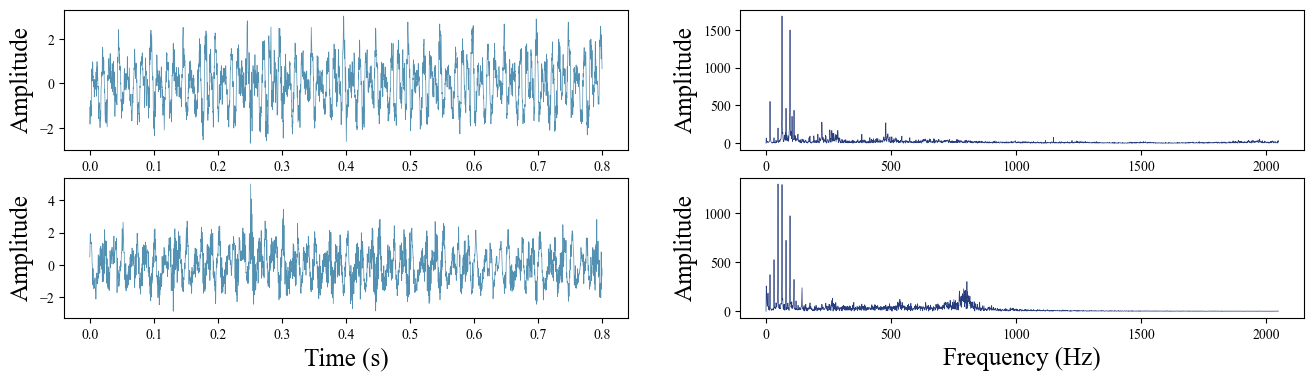

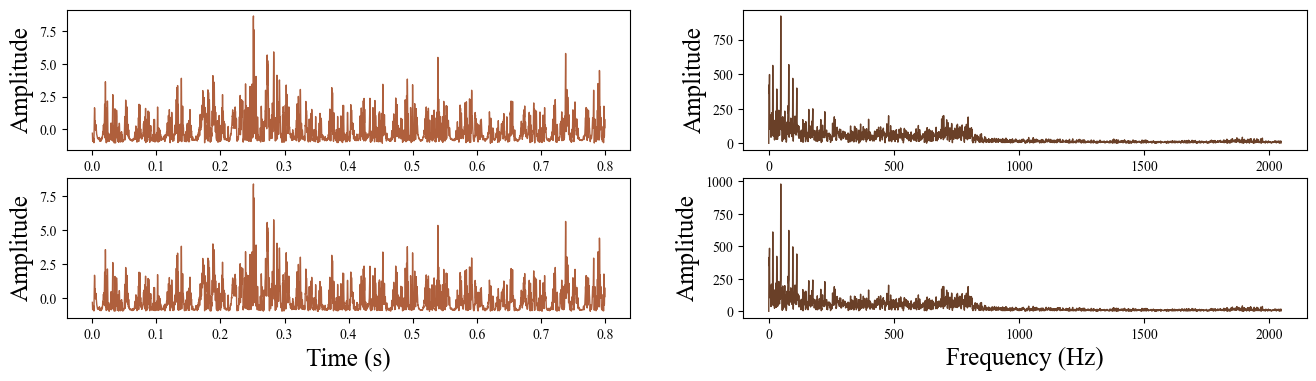

In [14]:
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
test_signal = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
# 确定每种类别的结束索引
end_indices = {label: idx for idx, label in enumerate(test_label)}
print(end_indices)
test_signal = torch.from_numpy(test_signal).cuda().float()
signal_num_list = [25, 260, 510, 770, 1070]
for signal_num in signal_num_list:
    torch.cuda.empty_cache()
    plot_ori_signal(signal_num, test_signal, fault_type_list[signal_num//253])
    output_signal = get_TSPN_signal(model.network.cuda(), test_signal, 3)[signal_num,:,:]
    output_signal = output_signal.T
    plot_signal(output_signal, fault_type_list[signal_num//253] + '_after.svg')
    # print(output_signal.shape)

In [18]:
with torch.no_grad():
    W = model.network.signal_processing_layers[1].weight_connection.weight  # [out,in]
    logits = W / model.network.signal_processing_layers[1].temperature
    top1 = logits.max(dim=1).values
    top2 = logits.topk(2, dim=1).values[:, 1]
    margin = (top1 - top2).mean().item()
    alpha = torch.softmax(logits, dim=1)
    entropy = (-(alpha * (alpha+1e-12).log()).sum(dim=1)).mean().item()
    print("avg top1-top2 margin:", margin, "avg entropy:", entropy)


avg top1-top2 margin: 0.9489339590072632 avg entropy: 1.9480841159820557


### weights

第1层信号贡献可视化：


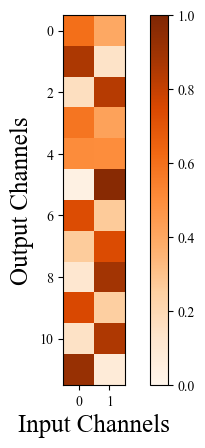

[[0.60434884 0.39565116]
 [0.8582852  0.14171481]
 [0.16464792 0.83535206]
 [0.58000183 0.4199982 ]
 [0.5000271  0.49997285]
 [0.0334917  0.9665083 ]
 [0.73359805 0.26640195]
 [0.26286075 0.7371393 ]
 [0.11667526 0.88332474]
 [0.74662596 0.25337404]
 [0.1478962  0.85210377]
 [0.9188515  0.08114849]]
[[0.3352576  0.6647424 ]
 [0.8567873  0.14321262]
 [0.14486095 0.855139  ]
 [0.35065877 0.6493412 ]
 [0.3315968  0.6684032 ]
 [0.44204962 0.55795044]
 [0.5778874  0.4221126 ]
 [0.34033248 0.65966755]
 [0.14762634 0.85237366]
 [0.81060994 0.18939006]
 [0.12344233 0.8765576 ]
 [0.90510833 0.09489165]]


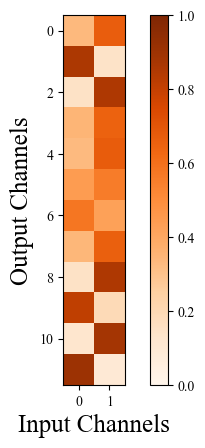

第2层信号贡献可视化：


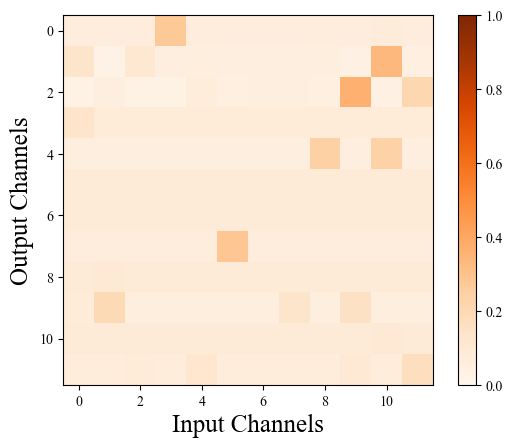

[[0.06536215 0.06513511 0.06508704 0.2745373  0.06528848 0.06525342
  0.06524373 0.06522741 0.06520525 0.0652383  0.07316971 0.06525214]
 [0.13150029 0.02262326 0.10606023 0.05461182 0.05494107 0.0543364
  0.05429051 0.05432257 0.05727056 0.0324018  0.3342078  0.04343364]
 [0.02662404 0.05186406 0.02389617 0.02615776 0.06691696 0.04527494
  0.05181028 0.05182365 0.04304365 0.36396953 0.03901752 0.20960137]
 [0.13541704 0.07825752 0.07831743 0.08086286 0.07846285 0.07837305
  0.07837014 0.07839478 0.07838316 0.07833158 0.07846342 0.0783662 ]
 [0.05730908 0.05147178 0.05148022 0.05148735 0.05150498 0.05148958
  0.05143341 0.05146704 0.24236244 0.05146133 0.23707905 0.05145378]
 [0.0832665  0.08329037 0.0833718  0.08327053 0.08327563 0.083431
  0.0833968  0.08328249 0.08337592 0.0832812  0.08335128 0.08340649]
 [0.08337775 0.08334766 0.08323763 0.08334864 0.08331345 0.08339251
  0.08323555 0.08336975 0.08335752 0.08336409 0.0832936  0.08336182]
 [0.06475871 0.06441996 0.06479352 0.0647674

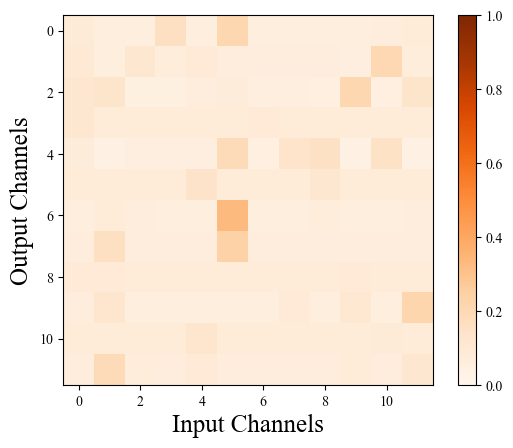

第3层信号贡献可视化：


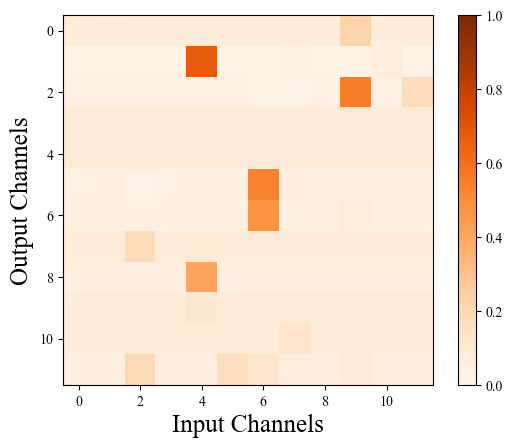

[[0.07042978 0.07521035 0.07033617 0.07044856 0.07049008 0.0704757
  0.07044619 0.07047512 0.07052042 0.22012569 0.07053313 0.07050887]
 [0.02607016 0.02606851 0.02602926 0.02607441 0.6740995  0.02609252
  0.02609603 0.02900616 0.02609563 0.02606577 0.06225759 0.02604443]
 [0.02809695 0.02814741 0.02790323 0.02830231 0.02847007 0.02844657
  0.02712388 0.02215217 0.02848329 0.5492508  0.0284734  0.17515004]
 [0.08319858 0.08336642 0.08333737 0.08329087 0.08335378 0.08333632
  0.08335578 0.08346368 0.08328383 0.08333858 0.0833228  0.08335195]
 [0.08329941 0.08336483 0.08319407 0.08330221 0.08336513 0.08336831
  0.08338276 0.08336733 0.08342338 0.08331142 0.08332887 0.08329229]
 [0.04099698 0.04441866 0.02304102 0.02929125 0.04540822 0.04538475
  0.5361643  0.05308206 0.04541131 0.04568205 0.04550513 0.04561433]
 [0.04627731 0.04636652 0.04614928 0.04629101 0.04628949 0.0462868
  0.47344482 0.04625554 0.04628248 0.06380507 0.0462588  0.04629285]
 [0.07179136 0.0718196  0.18193054 0.071717

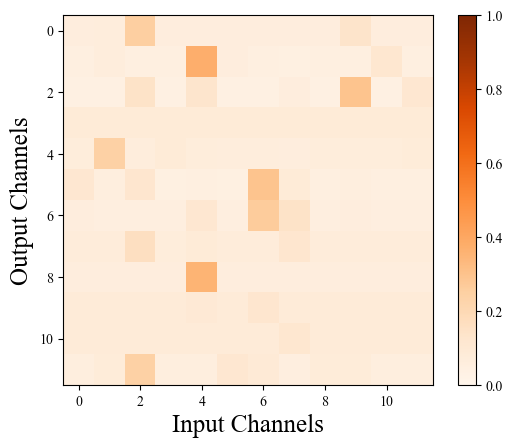

第4层信号贡献可视化：


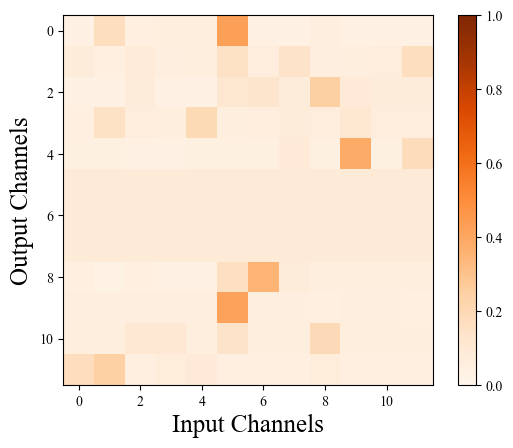

[[0.02862363 0.16565254 0.04432128 0.05832838 0.05781837 0.42697513
  0.0283472  0.0337355  0.05419345 0.03130431 0.03807927 0.03262091]
 [0.07112662 0.04732843 0.07648116 0.05181872 0.05620395 0.14878075
  0.06501671 0.13938926 0.05251319 0.05815175 0.06147208 0.1717174 ]
 [0.03173308 0.03479364 0.07172918 0.0291752  0.03446145 0.11328144
  0.1273347  0.0721352  0.2490351  0.09207574 0.07207059 0.07217474]
 [0.04776326 0.15270348 0.06247525 0.05743742 0.19496122 0.05670353
  0.06139153 0.07192209 0.06031879 0.1109362  0.06363714 0.05975008]
 [0.03954167 0.03958312 0.03843114 0.0344339  0.03956813 0.0394442
  0.03943776 0.09334549 0.03955208 0.37902737 0.03961355 0.17802165]
 [0.08330105 0.08329198 0.08340442 0.08342721 0.08311985 0.08338889
  0.08335377 0.08329223 0.08331966 0.08334325 0.08341005 0.08334767]
 [0.08323296 0.08345382 0.08336796 0.08326746 0.08335648 0.08331677
  0.08338742 0.08324669 0.08336736 0.08327261 0.08340486 0.08332559]
 [0.08335833 0.08346368 0.08332795 0.08331

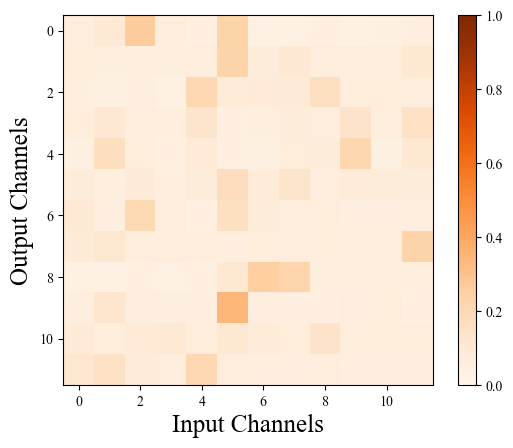

[[0.46816415 0.53183585]
 [0.46380022 0.53619975]
 [0.45691508 0.543085  ]
 [0.46084258 0.53915745]
 [0.4568436  0.5431564 ]
 [0.46382412 0.5361759 ]
 [0.46826878 0.53173125]
 [0.46262056 0.53737956]
 [0.46290153 0.5370984 ]
 [0.46041024 0.53958976]
 [0.46080846 0.53919154]
 [0.45762455 0.54237545]]
0.46191862 0.5380814


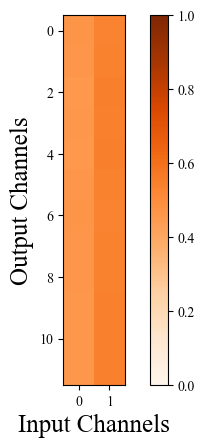

In [ ]:
def plot_weight(weight, name):
    plt.imshow(weight, cmap='Oranges')
    plt.xlabel('Input Channels', fontsize=18)
    plt.ylabel('Output Channels', fontsize=18)
    # colorbar范围0到1
    plt.clim(0, 1)
    plt.colorbar()
    plt.savefig('save/figure/seu/weight/'+ f'{name}.svg')
    # plt.clf()
    plt.show()

def visualize_signal_contribution(layer, savename):
    # main_weight = layer.weight_connection.weight.data.cpu().numpy()
    main_weight = layer.alpha_main.cpu().numpy()
    # skip_weight = layer.skip_connection.weight.data.cpu().numpy()
    skip_weight = layer.alpha_skip.cpu().numpy()
    total_weight = main_weight + skip_weight
    weight_norm = np.abs(total_weight) / np.abs(total_weight).sum(axis=1, keepdims=True)
    print(total_weight.shape)

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(weight_norm.shape[0]), weight_norm[:, 0], label='torque signal')
    plt.bar(np.arange(weight_norm.shape[0]), weight_norm[:, 1], bottom=weight_norm[:, 0], label='vibration signal')
    plt.xlabel('Channel Index', fontsize=18)
    plt.ylabel('Contribution Ratio', fontsize=18)
    plt.legend(fontsize=18)
    # plt.title('Total Contribution of Torque and Vibration Signals to Output Features')
    plt.savefig('save/figure/seu/weight/' + 'contribution_layer_' + savename + '.svg')
    plt.show()

weight_list = []
for i in range(4):
    print(f"第{i+1}层信号贡献可视化：")
    weight_sol = model.network.signal_processing_layers[i].alpha_main
    weight_sol = weight_sol.detach().cpu().numpy()
    # plot_weight(weight_sol, 'weight_sol_' + str(i))
    print(weight_sol)
    weight_skip_connect = model.network.signal_processing_layers[i].alpha_skip
    weight_skip_connect = weight_skip_connect.detach().cpu().numpy()
    weight_list.append((weight_sol + weight_skip_connect)/2)
    print(weight_list[i])
    plot_weight((weight_sol + weight_skip_connect)/2, 'weight_skip_connect_' + str(i))
    # layer = model.network.signal_processing_layers[i]
weight_all = weight_list[3] @ weight_list[2] @ weight_list[1] @ weight_list[0]
print(weight_all)
# 计算input0对应的和
print(weight_all[:, 0].sum()/12, weight_all[:, 1].sum()/12)
plot_weight(weight_all, 'weight_all')
    # visualize_signal_contribution(layer, str(i))

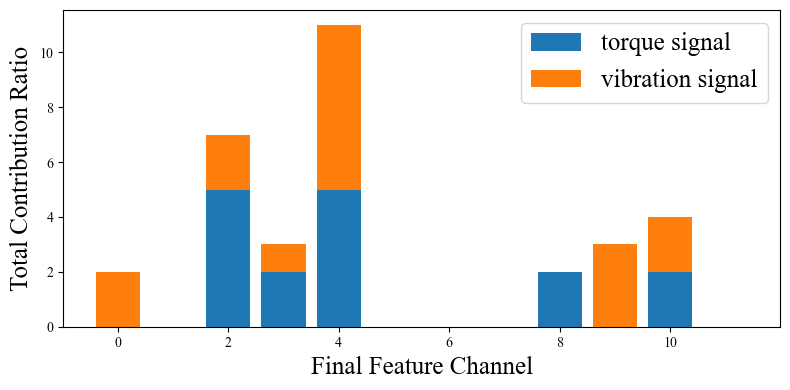

In [78]:
def get_total_contribution(model):
    weights = []
    for i, layer in enumerate(model.signal_processing_layers):
        main_weight = layer.weight_connection.weight.data.cpu().numpy()
        skip_weight = layer.skip_connection.weight.data.cpu().numpy()
        total_weight = main_weight + skip_weight
        weights.append(total_weight)
    W_total = weights[3] @ weights[2] @ weights[1] @ weights[0]
    return np.abs(W_total)

def plot_total_contribution(W_norm):
    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(W_norm.shape[0]), W_norm[:, 0], label='torque signal')
    plt.bar(np.arange(W_norm.shape[0]), W_norm[:, 1], bottom=W_norm[:, 0], label='vibration signal')
    plt.xlabel('Final Feature Channel', fontsize=18)
    plt.ylabel('Total Contribution Ratio', fontsize=18)
    plt.legend(fontsize=18)
    # plt.title('Contribution of Torque and Vibration Signals to Final Features')
    plt.tight_layout()
    # plt.show()
    plt.savefig('save/figure/seu/weight/' + 'total_contribution.svg')
W_norm = get_total_contribution(model.network)
plot_total_contribution(W_norm)

### rader plot

(1270, 13)
(5, 13)
(5, 13)
(5, 13)
(5, 13)
(5, 13)
(5, 13)
(5, 13)


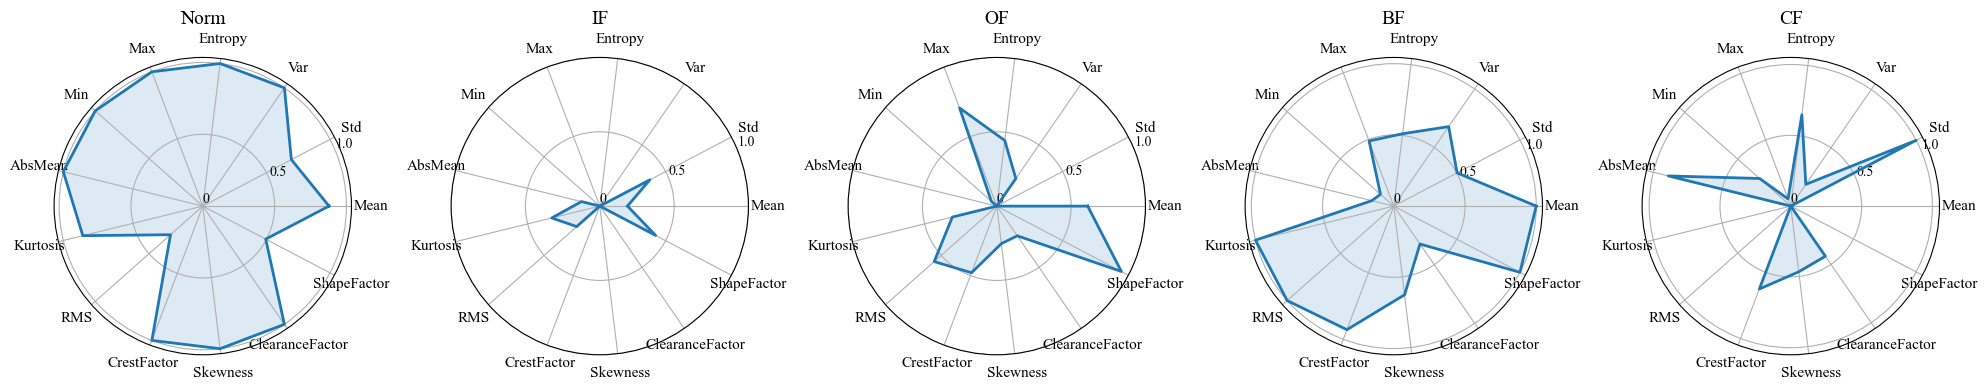

In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def extract_eaff_feature(model, test_signal):
    # 前向传播，获得所有样本的最终特征向量 F
    with torch.no_grad():
        for layer in model.signal_processing_layers:
            test_signal = layer(test_signal)
        # 特征提取层输出 shape: [样本数, 特征数]
        F = model.feature_extractor_layers(test_signal)  # [N, 13]
    return F.detach().cpu().numpy()

def aggregate_by_class(F, labels, num_classes=5):
    # 按类别聚合，计算每类的均值特征
    mean_features = []
    for i in range(num_classes):
        class_features = F[labels == i]  # shape: [样本数, 13]
        # 取特定的样本而非整体
        class_features = class_features[:5, :]  # 只取前5个样本
        print(class_features.shape)
        mean_feat = class_features.mean(axis=0)  # shape: [13]
        mean_features.append(mean_feat)
    return np.array(mean_features)

def normalize_features(mean_features):
    # 对每个特征轴归一化到[0,1]
    min_vals = mean_features.min(axis=0)
    max_vals = mean_features.max(axis=0)
    normed = (mean_features - min_vals) / (max_vals - min_vals + 1e-8)
    return normed

def plot_radar_subplots(normed_features, feature_names, fault_type_list):
    plt.rcParams['font.family'] = 'Times New Roman'
    num_classes = len(fault_type_list)
    num_features = len(feature_names)
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # 闭合

    fig, axs = plt.subplots(1, num_classes, subplot_kw=dict(polar=True), figsize=(4*num_classes, 5))
    if num_classes == 1:
        axs = [axs]
    for i, ax in enumerate(axs):
        data = normed_features[i].tolist()
        data += data[:1]
        ax.plot(angles, data, color='#1f77b4', linewidth=2)
        ax.fill(angles, data, color='#1f77b4', alpha=0.15)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_names, fontsize=11)
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(['0', '0.5', '1.0'], fontsize=10)
        ax.set_title(fault_type_list[i], fontsize=14)
    plt.tight_layout()
    plt.savefig('save/figure/seu/feature/fault_signature_radar_subplots.svg')
    plt.show()

# 主流程
feature_names = ['Mean', 'Std', 'Var', 'Entropy','Max', 'Min', 'AbsMean', 'Kurtosis', 'RMS', 'CrestFactor','Skewness', 'ClearanceFactor', 'ShapeFactor']
fault_type_list = ['Norm','IF','OF','BF','CF']

test_data = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
test_signal = torch.from_numpy(test_data).float().cuda()
test_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")

F = extract_eaff_feature(model.network, test_signal)  # shape: [N, 156]
F = F.reshape(F.shape[0], 12, 13).mean(axis=1)        # shape: [N, 13]，对通道求均值
print(F.shape)  # 应为 (1270, 13)
mean_features = aggregate_by_class(F, test_label, num_classes=5)  # shape: [5, 13]
print(mean_features.shape)
normed_features = normalize_features(mean_features)  # shape: [5, 13]
print(normed_features.shape)
plot_radar_subplots(normed_features, feature_names, fault_type_list)

### UMAP 函数

In [55]:
import umap.umap_ as umap
def plot_Umap(feature, y_label, fault_type_list, savename='umap_plot'):
    plt.rcParams['font.family'] = 'Times New Roman'
    # n_neighbors 控制局部邻域的大小，较小的值关注局部结构，较大的值关注全局结构
    # min_dist 控制嵌入点之间的最小距离
    # n_components 是降维后的维度，通常为 2 以便可视化
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

    # 使用特征数据拟合模型并进行降维
    embedding = reducer.fit_transform(feature.detach().cpu().numpy())

    # 可视化
    plt.figure(figsize=(8, 6))

    # 使用不同的颜色绘制不同类别的点
    color_list = ['#98C897', '#9C6BA3', '#9DBAD2', '#FE9C9D',
                  '#858A2E', '#356529', '#611A44', '#832F87',
                  '#291173', '#A75265']
    unique_labels = np.unique(y_label)

    for i, label in enumerate(unique_labels):
        idx = y_label == label
        plt.scatter(embedding[idx, 0], embedding[idx, 1], color=color_list[i], label=fault_type_list[int(label)] if int(label) < len(fault_type_list) else f'类别 {int(label)}', s=50) # s是点的大小

    # plt.title('UMAP projection of the features', fontsize=15)
    plt.legend(fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # 保存图像
    plt.savefig('save/figure/' + savename + '_umap.svg')

### 计算特征函数

In [56]:
def get_TSPN_feature(model, signal):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
        x = model.feature_extractor_layers(signal)
    return x

### tspn_umap

(1270, 4096, 2)
torch.Size([1270, 156])
(1270,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


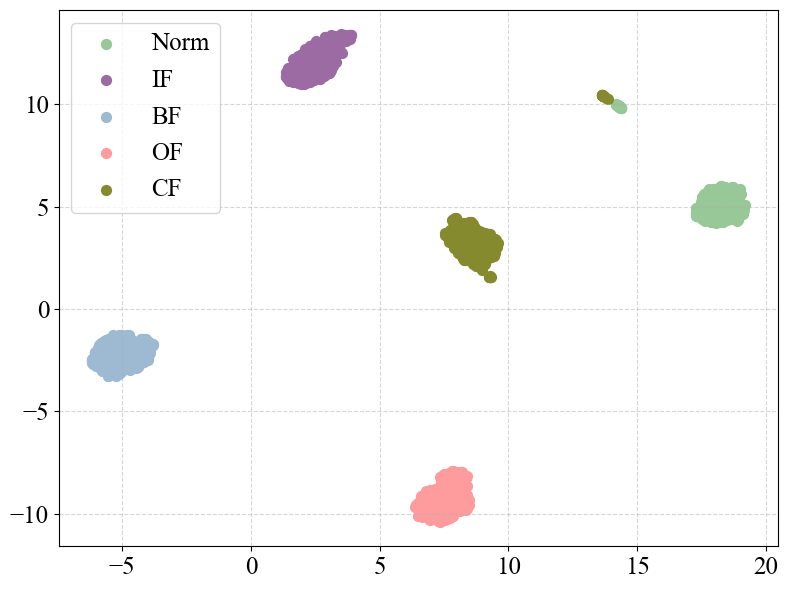

In [57]:
test_signal = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_TSPN_feature(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/tspn')

## Resnet

### import model

In [58]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_Resnet_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/resnet.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Resnettime20-15-57-11_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [59]:
def get_Resnet_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b c n -> b n c')
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        output = x.view(x.size(0), -1)
    return output

### resnet_umap

(1270, 4096, 2)
torch.Size([1270, 512])
(1270,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


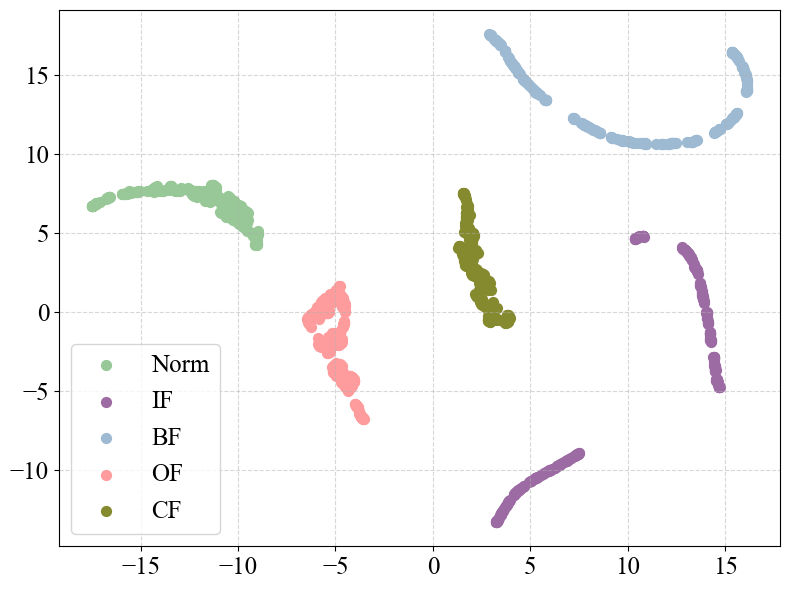

In [60]:
test_signal = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_Resnet_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/resnet')

## Sincnet

### import model

In [61]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_Sincnet.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/sincnet.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Sinc_net_mtime20-15-57-13_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [62]:
def get_sincnet_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b c n -> b n c')
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        output = x.view(x.size(0), -1)
    return output

### sincnet_umap

(1270, 4096, 2)
torch.Size([1270, 512])
(1270,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


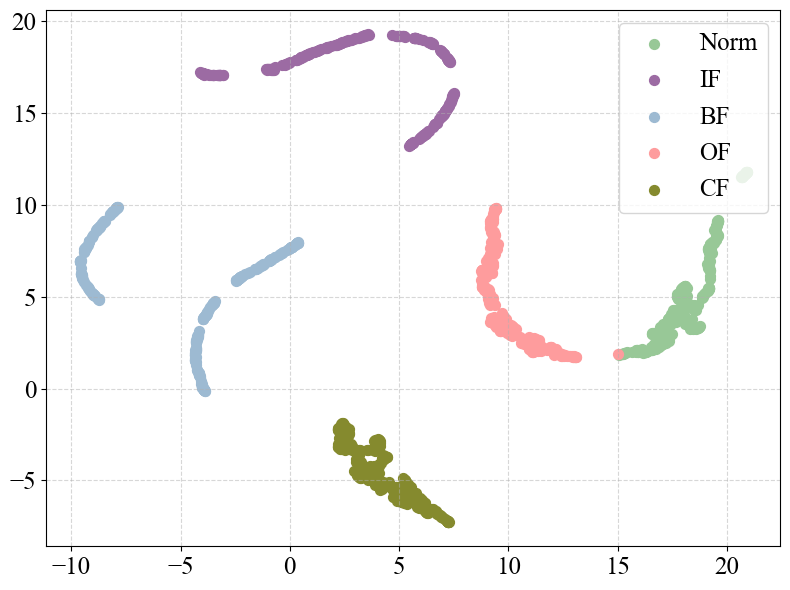

In [63]:
test_signal = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_sincnet_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/sincnet')

## MWACNN

### import model

In [64]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_MWA_CNN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/mwacnn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Huan_nettime20-15-57-16_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [65]:
def get_MWA_CNN_signal(model, signal):
    with torch.no_grad():
        input = rearrange(signal, 'b l c -> b c l')
        DMT_yl,DMT_yh = model.DWT0(input)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1)
            
        output = model.SConv1(output)
        DMT_yl,DMT_yh = model.DWT1(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1)
        output = model.dropout1(output)
        output = model.cSE1(output)
            
        output = model.SConv2(output)
        DMT_yl,DMT_yh = model.DWT2(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1) 
        output = model.dropout2(output)
        output = model.cSE2(output)
            
        output = model.SConv3(output)
        DMT_yl,DMT_yh = model.DWT3(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1) 
        output = model.dropout3(output)
        output = model.cSE3(output)
            
        output = model.SConv6(output)
        output = model.avg_pool(output)
        output = output.view(output.size(0), -1)
    return output

### mwacnn_umap

(1270, 4096, 2)
torch.Size([1270, 96])
(1270,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


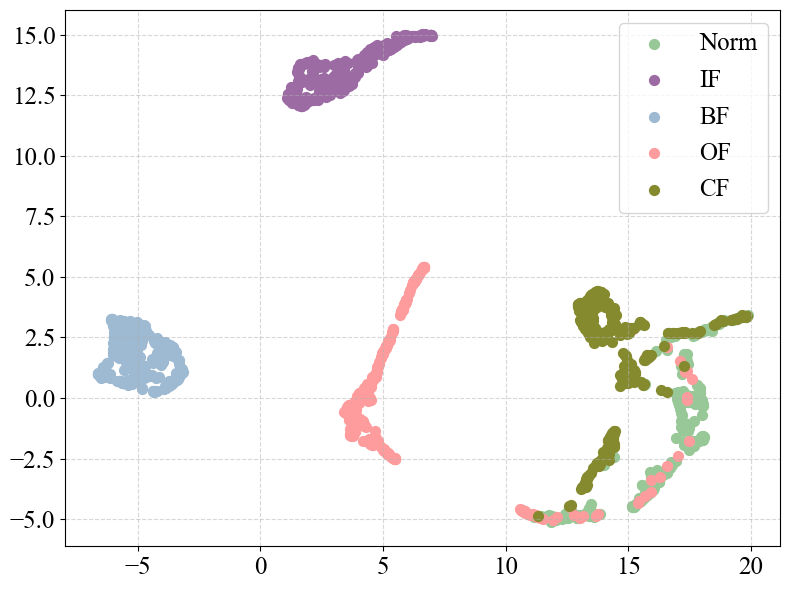

In [66]:
test_signal = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_MWA_CNN_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/mwacnn')

## MCN

### import model

In [67]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_MCN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/mcn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_MCN_GFKtime20-15-57-18_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [68]:
def get_mcn_signal(model, signal):
    with torch.no_grad():
        out = torch.cat([model.features[i](signal[:, :, i].unsqueeze(1)) for i in range(len(model.features))], dim=1)
        out = model.conv(out.real)
        out = model.AdpAvgpool(out)
        out = model.flatten(out)
        out = model.fc(out)
    return out

### mcn_umap

(1270, 4096, 2)
torch.Size([1270, 5])
(1270,)


d:\anaconda3\envs\phm_bench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


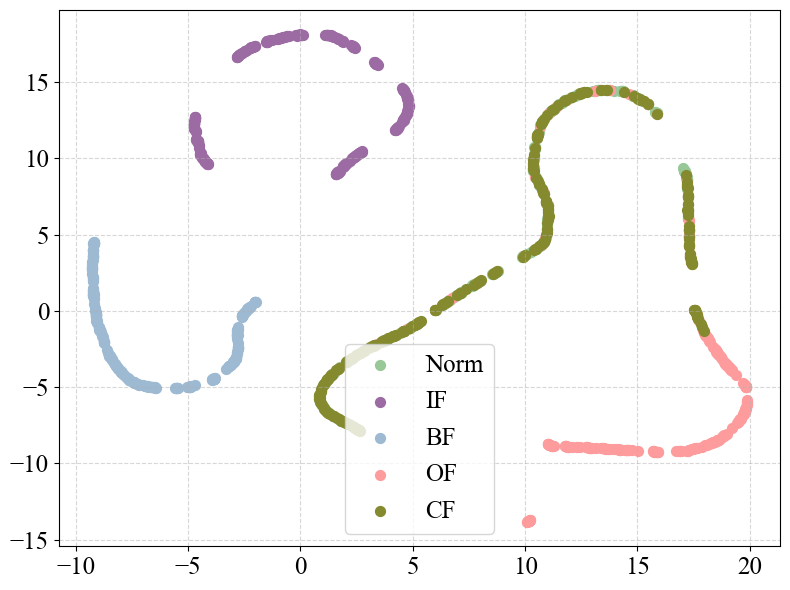

In [69]:
test_signal = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_mcn_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dataset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/mcn')